In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from grb.io import read_data, filter_data
from grb.const import TRIGGER_TIME
from grb.analysis import Analyzer

from grb.functions import *
from grb.prior import *
from grb.extinction import host_galaxy_extinction, host_galaxy_extinction_curve

from grb.utils import unit_conversion
from grb.sed import *

/data9/hongyp/GRB251013C/GRB_fitting/grb/fit.py:324: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"


## 7DT SED fit

In [3]:
df_sdt = read_data("sdt_tractor", correct_galactic_extinction=True, add_converted_flux=True)
x0 = pivot_finder(df_sdt["frequency_Hz"], df_sdt["flux_mJy"], df_sdt["flux_error_mJy"])
print(x0/1e14)

Optimal Pivot: 5.89e+14
5.890357260304238


/data9/hongyp/GRB251013C/GRB_fitting/grb/extinction.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  uncorrected_df[magnitude_column] -= extinc
/data9/hongyp/GRB251013C/GRB_fitting/grb/utils.py:36: FutureWarning: ChainedAssignmentError: 

In [3]:
df_sdt["frequency_Hz"]

0     6.311420e+14
1     3.893409e+14
2     7.494811e+14
3     7.053940e+14
4     6.662055e+14
5     6.311420e+14
6     5.995849e+14
7     5.710333e+14
8     5.450772e+14
9     5.213782e+14
10    4.996541e+14
11    4.796679e+14
12    4.612192e+14
13    4.441370e+14
14    4.282749e+14
15    3.997233e+14
16    3.868290e+14
17    3.747406e+14
18    3.633848e+14
19    3.526970e+14
20    3.426200e+14
21    4.796679e+14
Name: frequency_Hz, dtype: float64

In [4]:
df_sdt

,magnitude,mag_error,wavelength,filter_width,is_upper_limit,filter_name,units,aperture_size,image_path,exposure,...,cat_mag,cat_mag_err,aper_mag,aper_mag_err,gal_extinction,gal_corrected,frequency_Hz,frequency_error_Hz,flux_mJy,flux_error_mJy
0,17.641363,0.007166,4750,1150,False,g,7DT,0.0,NaN,300.0,...,17.838373,0.007166,17.838373,0.007166,0.197010,True,6.311420e+14,8.692375e+13,0.318773,0.002104
1,17.099452,0.029592,7700,1000,False,i,7DT,0.0,NaN,300.0,...,17.196110,0.029592,17.196110,0.029592,0.096658,True,3.893409e+14,2.703756e+13,0.525104,0.014312
2,17.474977,0.043746,4000,250,False,m400,7DT,0.0,NaN,300.0,...,17.708243,0.043746,17.708243,0.043746,0.233266,True,7.494811e+14,2.417681e+13,0.371566,0.014971
3,17.611772,0.026711,4250,250,False,m425,7DT,0.0,NaN,300.0,...,17.833397,0.026711,17.833397,0.026711,0.221625,True,7.053940e+14,2.137558e+13,0.327580,0.008059
4,17.404158,0.021122,4500,250,False,m450,7DT,0.0,NaN,300.0,...,17.613911,0.021122,17.613911,0.021122,0.209753,True,6.662055e+14,1.903444e+13,0.396609,0.007716
5,17.321945,0.016849,4750,250,False,m475,7DT,0.0,NaN,300.0,...,17.518955,0.016849,17.518955,0.016849,0.197010,True,6.311420e+14,1.705789e+13,0.427808,0.006639
6,17.344063,0.022594,5000,250,False,m500,7DT,0.0,NaN,300.0,...,17.527872,0.022594,17.527872,0.022594,0.183810,True,5.995849e+14,1.537397e+13,0.419181,0.008723
7,17.478947,0.020603,5250,250,False,m525,7DT,0.0,NaN,300.0,...,17.650275,0.020603,17.650275,0.020603,0.171327,True,5.710333e+14,1.392764e+13,0.370209,0.007025
8,17.267263,0.025421,5500,250,False,m550,7DT,0.0,NaN,300.0,...,17.427520,0.025421,17.427520,0.025421,0.160257,True,5.450772e+14,1.267621e+13,0.449905,0.010534
9,17.289234,0.029507,5750,250,False,m575,7DT,0.0,NaN,300.0,...,17.439935,0.029507,17.439935,0.029507,0.150701,True,5.213782e+14,1.158618e+13,0.440892,0.011982


In [5]:
eta = host_galaxy_extinction_curve(df_sdt["frequency_Hz"])
combined_func = lambda x, *params: power_law(x, *params[:2], x0=x0) * host_galaxy_extinction(x, *params[2:], eta=eta)

param_bounds, prior = power_law_prior(data_type="sed")
param_bounds_ext, prior_ext = host_galaxy_extinction_prior()
param_bounds.update(param_bounds_ext)
prior.update(prior_ext)

alz_sed = Analyzer(df_sdt["frequency_Hz"], df_sdt["flux_mJy"], combined_func, data_type="sed", y_data_error=df_sdt["flux_mJy_error"], x_data_error=df_sdt["frequency_Hz_error"], param_bounds=param_bounds, prior=prior)
alz_sed.run()

16:12 bilby INFO    : Running for label 'grb_fit', output will be saved to 'bilby_out'
16:12 bilby INFO    : Analysis priors:
16:12 bilby INFO    : F_pl=LogUniform(minimum=0.01, maximum=1000.0, name='F_pl', latex_label='F_pl', unit=None, boundary=None)
16:12 bilby INFO    : beta=Uniform(minimum=0, maximum=3, name='beta', latex_label='beta', unit=None, boundary=None)
16:12 bilby INFO    : Av=LogNormal(mu=-1.8881197762551172, sigma=0.9440598881275586, name='Av', latex_label='Av', unit=None, boundary=None)
16:12 bilby INFO    : Analysis likelihood class: <class 'grb.fit._BilbyFitterLikelihood.__new__.<locals>.BilbyLikelihood'>
16:12 bilby INFO    : Analysis likelihood noise evidence: nan
16:12 bilby INFO    : Single likelihood evaluation took nan s
16:12 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 800, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'p

5442it [00:00, ?it/s]

16:12 bilby INFO    : Written checkpoint file bilby_out/grb_fit_resume.pickle
16:13 bilby INFO    : Rejection sampling nested samples to obtain 1384 posterior samples
16:13 bilby INFO    : Sampling time: 0:08:27.836410


[ultranest] Explored until L=-7e+02  .35 [-654.8118..-654.8117]*| it/evals=5700/125228 eff=4.5626% N=300      0 0  
[ultranest] Likelihood function evaluations: 125327
[ultranest]   logZ = -669.1 +- 0.1368
[ultranest] Effective samples strategy satisfied (ESS = 1680.6, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.14, need <0.5)
[ultranest]   logZ error budget: single: 0.20 bs:0.14 tail:0.01 total:0.14 required:<0.50
[ultranest] done iterating.


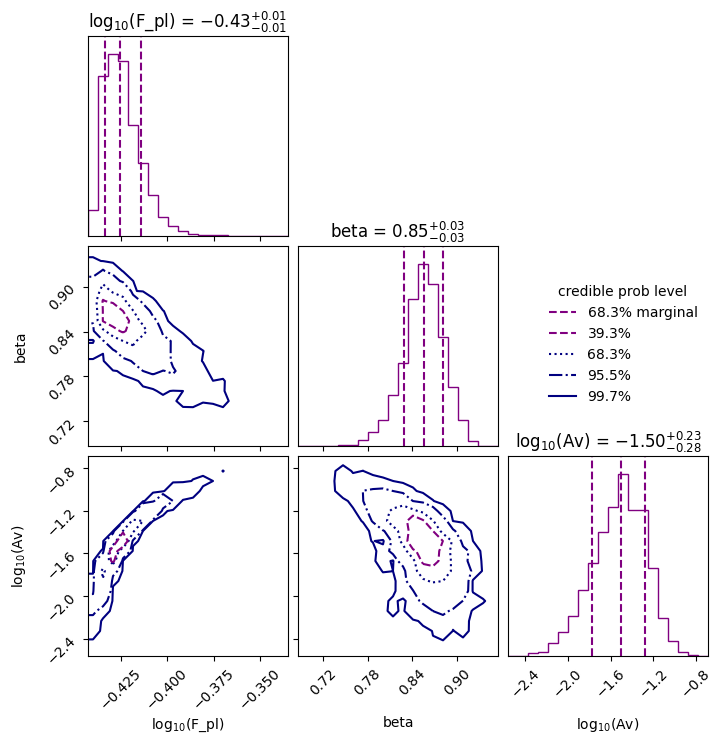

In [6]:
import bilby
bilby.__file__

In [ ]:
ultranest.__file__

'/home/dtak/miniconda3/envs/grb251013c/lib/python3.9/site-packages/ultranest/__init__.py'

In [13]:
alz_sed.sampler.posterior

,F_pl,beta,Av,log_likelihood,log_prior
0,0.314230,0.800476,0.162560,-62.112600,-1.431975
1,0.295794,0.973609,0.116310,-59.962862,-1.072783
2,0.389982,0.893686,0.300996,-58.779758,-2.526279
3,0.357976,0.670146,0.259261,-58.658529,-2.188748
4,0.279687,1.019179,0.065160,-57.940391,-0.796943
...,...,...,...,...,...
1379,0.314788,0.946017,0.138826,-52.150965,-1.277259
1380,0.336083,0.887610,0.192265,-52.148249,-1.696288
1381,0.320356,0.924575,0.153988,-52.144694,-1.394417
1382,0.330927,0.896298,0.179270,-52.144383,-1.594809


In [ ]:
alz_sed.results["weighted_samples"]

{'points': array([[0.31422984, 0.80047632, 0.16255955],
        [0.29579396, 0.97360862, 0.11631006],
        [0.38998156, 0.89368571, 0.30099643],
        ...,
        [0.32035619, 0.92457545, 0.15398751],
        [0.33092747, 0.89629831, 0.17926992],
        [0.33335785, 0.8908494 , 0.18603064]])}

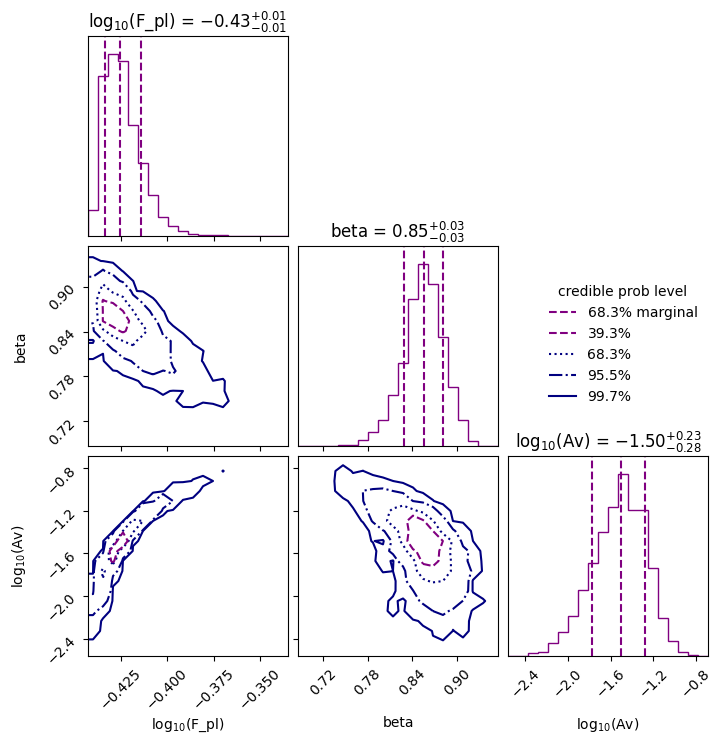

In [8]:
alz_sed.plot_corner()

In [7]:
alz_sed.results

{'niter': 6005,
 'logz': -669.0935256041439,
 'logzerr': 0.33795784859081424,
 'logz_bs': -669.1128541396471,
 'logz_single': -669.0935256041439,
 'logzerr_tail': 0.009938157036458506,
 'logzerr_bs': 0.3378116937864206,
 'ess': 1680.6263701141436,
 'H': 12.02123502402037,
 'Herr': 0.12239545520932255,
 'posterior': {'mean': [0.3770546422357986,
   0.8537762606458409,
   0.034919839343003176],
  'stdev': [0.00891066012603179, 0.027735158136545313, 0.019399215059967827],
  'median': [0.3755526218903786, 0.8548994546736077, 0.03141913877098244],
  'errlo': [0.3686785847607101, 0.828720279573903, 0.016544362157277604],
  'errup': [0.38523432372032707, 0.8811673199294755, 0.0529305615078464],
  'information_gain_bits': [4.143879076498822,
   3.4780596926124963,
   0.12667848078453547]},
 'weighted_samples': {'upoints': array([[9.99238369e-01, 7.37469933e-01, 3.67631224e-01],
         [9.88970193e-01, 8.16555691e-01, 3.81165066e-01],
         [9.90159046e-01, 5.69987758e-01, 2.98225227e-01],

<Axes: xlabel='Frequency', ylabel='Flux'>

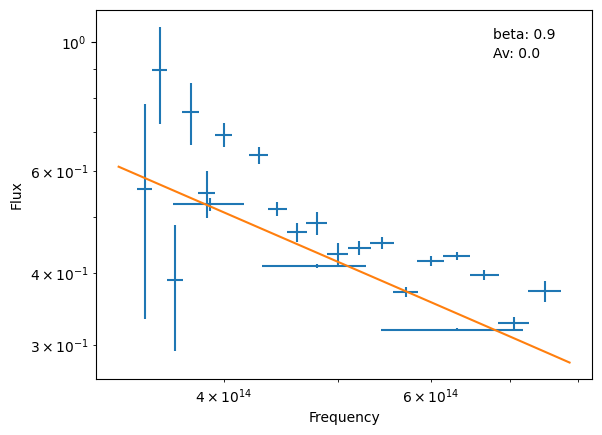

In [9]:
alz_sed.plot_data()
alz_sed.plot_model(show_param=True)


In [ ]:
df_xrt = read_data("xrt")
# df_filtered = filter_data(df_xrt, exclude_time_range = (3e3,  1e4))
# y_err = np.array([max(np.abs(high), np.abs(low)) for high, low in zip(df_filtered["Flux_high"], df_filtered["Flux_low"])])
# alz_xrt = Analyzer(df_filtered["Time"]/3600, df_filtered["Flux"], power_law, y_data_error=y_err)
#alz_xrt.run(method="curve_fit")

NameError: name 'alz_xrt' is not defined

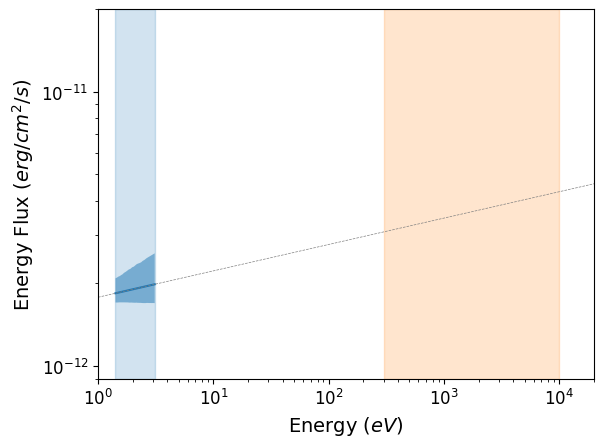

In [13]:
ax = plt.gca()

nu_grid = np.geomspace(min(alz_sed.x_data), max(alz_sed.x_data), 100)

power_law_sed = lambda x, *params: power_law(x, *params[:2], x0=x0)
dataset = alz_sed.get_posterior_predictive_curve(nu_grid, model=power_law_sed, param_indices=[0, 1])

plot_sed(nu_grid, power_law(nu_grid, *alz_sed.best_fit_params[:2], x0=x0), ax=ax, y_unit="sed", x_unit="eV", label="7DT (6.5 hrs)")
plot_sed_from_samples(dataset, ax=ax, y_unit="sed", x_unit="eV")

extrapolate_range = np.geomspace(unit_conversion(1, "eV", "Hz"), unit_conversion(200, "keV", "Hz"), 100)
plot_sed(extrapolate_range, power_law(extrapolate_range, *alz_sed.best_fit_params[:2], x0=x0), ax=ax, y_unit="sed", x_unit="eV", color="gray", ls="--", lw=0.5)

ax.set_xlim(1, 20000)
ax.set_ylim(9e-13, 2e-11)

ax.axvspan(unit_conversion(min(alz_sed.x_data), "Hz", "eV"), unit_conversion(max(alz_sed.x_data), "Hz", "eV"), color="C0", alpha=0.2)
ax.axvspan(300, 10000, color="C1", alpha=0.2)

ax.plot([300, 10000], [alz_xrt.model(6.5), alz_xrt.model(6.5)], color="C1", ls="--", label="XRT (interpolated at 6.5 hrs)")
ax.legend()
ax.grid()

In [ ]:
from grb.utils import unit_conversion

In [ ]:
10**((np.log10(10000)+np.log10(300))/2)

In [ ]:
data = alz_sed.get_posterior_predictive_curve([unit_conversion(2000, "eV", "Hz")], model=power_law_sed, param_indices=[0, 1])

In [ ]:
data_erg = mJy_to_erg_cm2_s(data[0][1:], unit_conversion(2000, "eV", "Hz"))

In [ ]:
alz_xrt.plot_data(label="XRT")
ax = alz_xrt.plot_model(color="red", lw=0.5, alpha=0.5)
ax.errorbar(6.5, data_erg[1], yerr=[[data_erg[1]-data_erg[0]], [data_erg[2]-data_erg[1]]])
ax.axvline(6.5, color="C1", ls=":", label="XRT (predicted at 6.5 hrs)")
